# DKIST/DL-NIRSP Level 1 Dataset Example for Arm 3 Fe I 1565 nm
Sarah Jaeggli | sjaeggli@nso.edu | 5 March 2026 \
with input from Tom Schad and Tetsu Anan

In [1]:
import dkist
import astropy.units as u

from sunpy.net import Fido, attrs as a
import sunpy.map
from astropy.time import Time

from scipy.interpolate import griddata

from glob import glob
import numpy as np
import matplotlib.pyplot as plt

In [2]:
## Change these to reflect your data directory and the dataset ID for the dataset that you want to work with
datadir = '/Users/sjaeggli/Projects/Data/DKIST/data2114'
recid = 'ROGALI'

## Read in the tiled dataset

In [3]:
## Find ASDF file
asdf_file = glob('{:}/{:}/*.asdf'.format(datadir, recid))

## Load DKIST tiled dataset
tds = dkist.load_dataset(asdf_file)

## Explore the dataset

In [4]:
tds

This DL-NIRSP Dataset is an array of (29, 13) Dataset objects and
consists of 1508 frames.
Files are stored in /Users/sjaeggli/Projects/Data/DKIST/data2114/ROGALI

This calibration has Dataset ID ROGALI.
The unique identifier for the input observe frames (Product ID) is L1-RWEJL.

Each Dataset has 4 pixel and 4 world dimensions.

The data are represented by a <class 'dask.array.core.Array'> object:
dask.array<load_files, shape=(4, 247, 68, 54), dtype=float32, chunksize=(1, 247, 68, 54), chunktype=numpy.ndarray>

Array Dim  Axis Name                  Data size  Bounds
        0  polarization state                 4  None
        1  dispersion axis                  247  None
        2  helioprojective latitude          68  None
        3  helioprojective longitude         54  None

World Dim  Axis Name                  Physical Type                   Units
        3  stokes                     phys.polarization.stokes        unknown
        2  wavelength                 em.wl            

In [5]:
## Get number of X and Y tiles in tiled dataset
## Note that x,y ordering of the tiles is reversed from the python array convention
nXtiles,nYtiles = tds.shape

## Get the dimensions of each tile
nS,nW,nY,nX = tds[0,0].data.shape

## Make a summary
print('Number of X Tiles:', nXtiles)
print('Number of Y Tiles:', nYtiles)
print('Axis names:', tds[0,0].wcs.pixel_axis_names) #these are listed in reverse order with respect to indexing in python
print('Number of Stokes Parameters:', nS)
print('Number of Wavelength Pixels:', nW)
print('Number of Spatial Y Pixels:', nY)
print('Number of Spatial X Pixels:', nX)
print('Waveband:', tds[0,0].headers[0]['WAVEBAND'])

Number of X Tiles: 29
Number of Y Tiles: 13
Axis names: ('helioprojective longitude', 'helioprojective latitude', 'dispersion axis', 'polarization state')
Number of Stokes Parameters: 4
Number of Wavelength Pixels: 247
Number of Spatial Y Pixels: 68
Number of Spatial X Pixels: 54
Waveband: Fe I (1565.0 nm)


In [6]:
xt0 = int(nXtiles/2)
yt0 = int(nYtiles/2)
x0 = int(nX/4)
y0 = int(nY/4)
w0 = 80 #spectral pixel in the blue wing of Stokes V profile

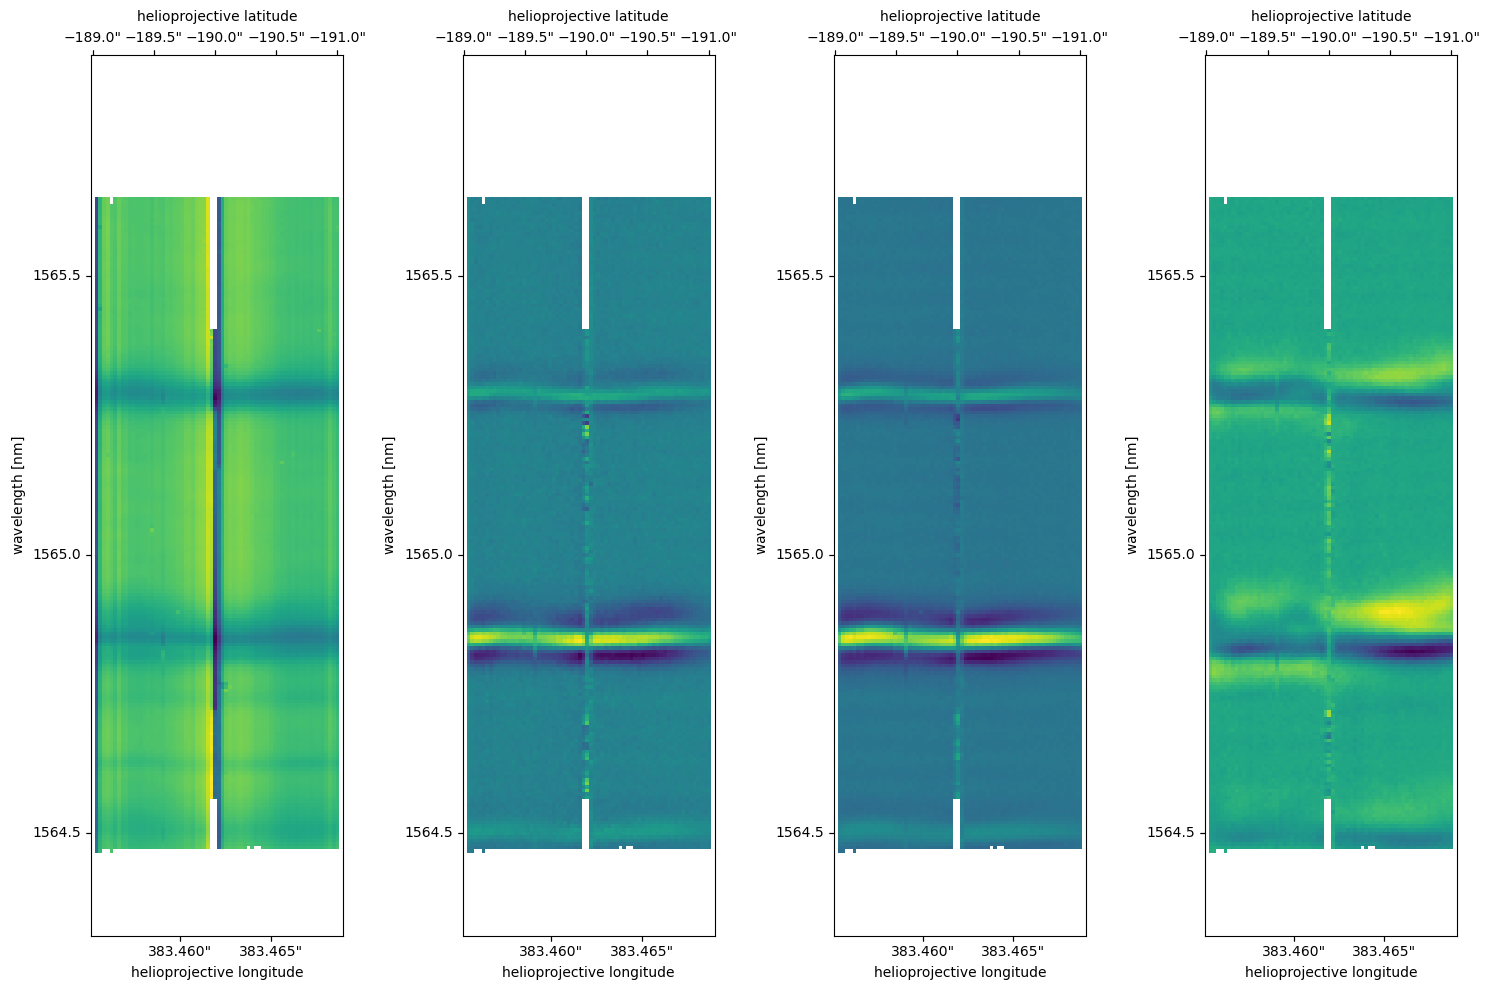

In [7]:
## Show the Stokes spectra from a single tile, taking a slice in the x-direction
fig = plt.figure(figsize=(15,10))

for iS in range(0,nS):
    ax = fig.add_subplot(1,4,iS+1, projection=tds[xt0,yt0][iS,:,:,x0])
    tds[xt0,yt0][iS,:,:,x0].plot(axes=ax, aspect='auto')

plt.tight_layout()
plt.show()

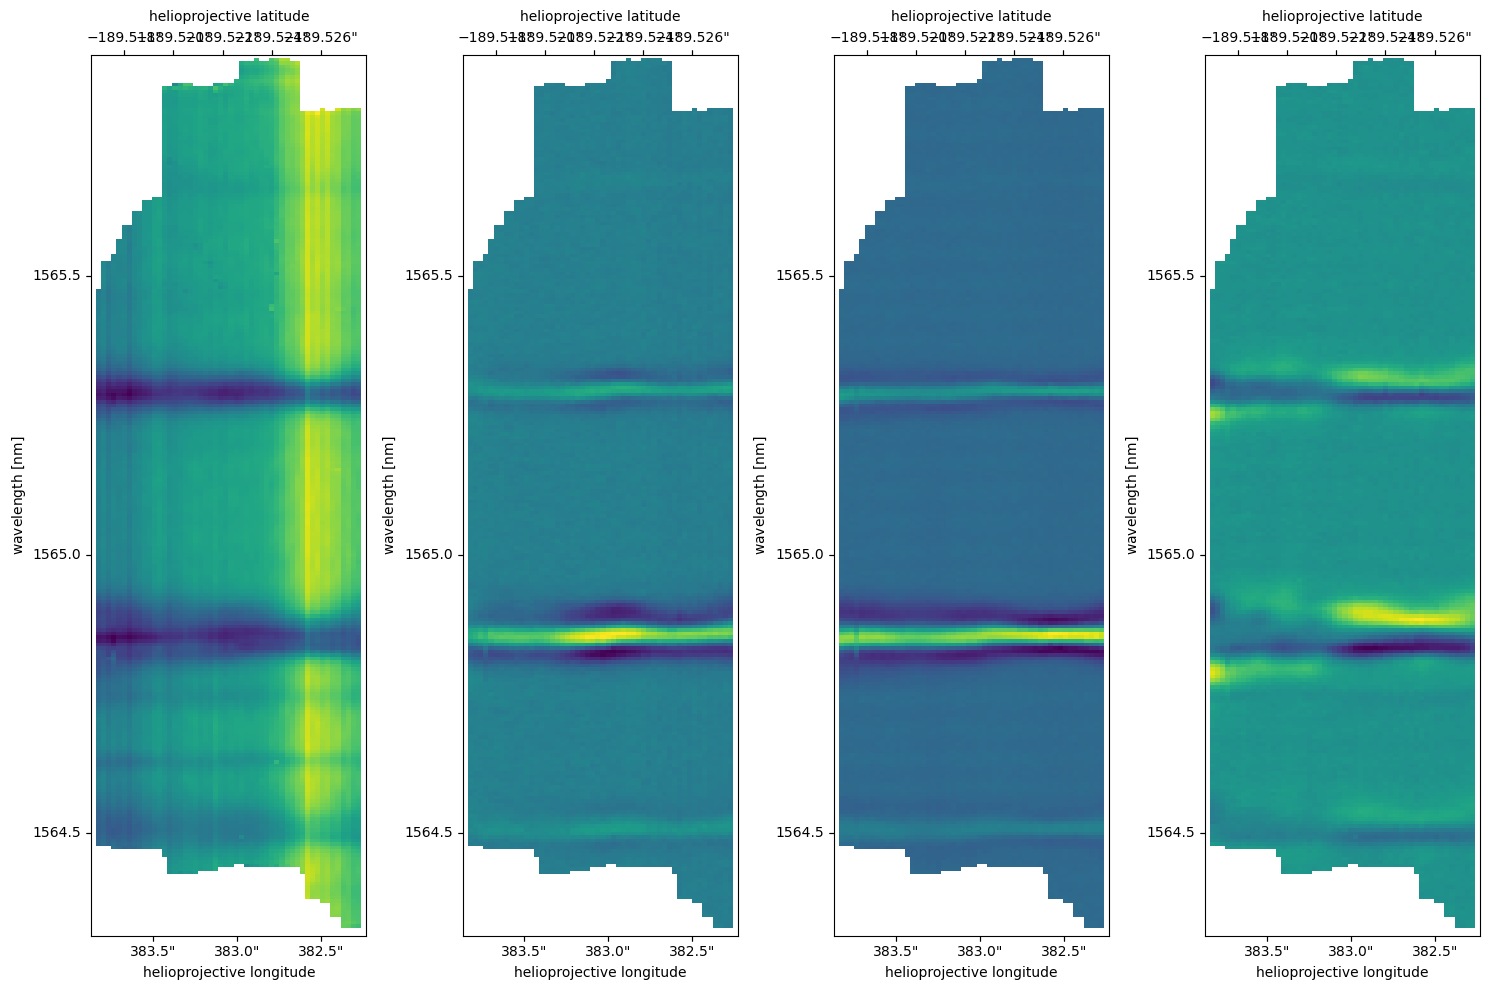

In [8]:
## Show the Stokes spectra from a single tile, taking a slice in the y-direction
fig = plt.figure(figsize=(15,10))

for iS in range(0,nS):
    ax = fig.add_subplot(1,4,iS+1, projection=tds[xt0,yt0][iS,:,y0,:])
    tds[xt0,yt0][iS,:,y0,:].plot(axes=ax, aspect='auto')

plt.tight_layout()
plt.show()

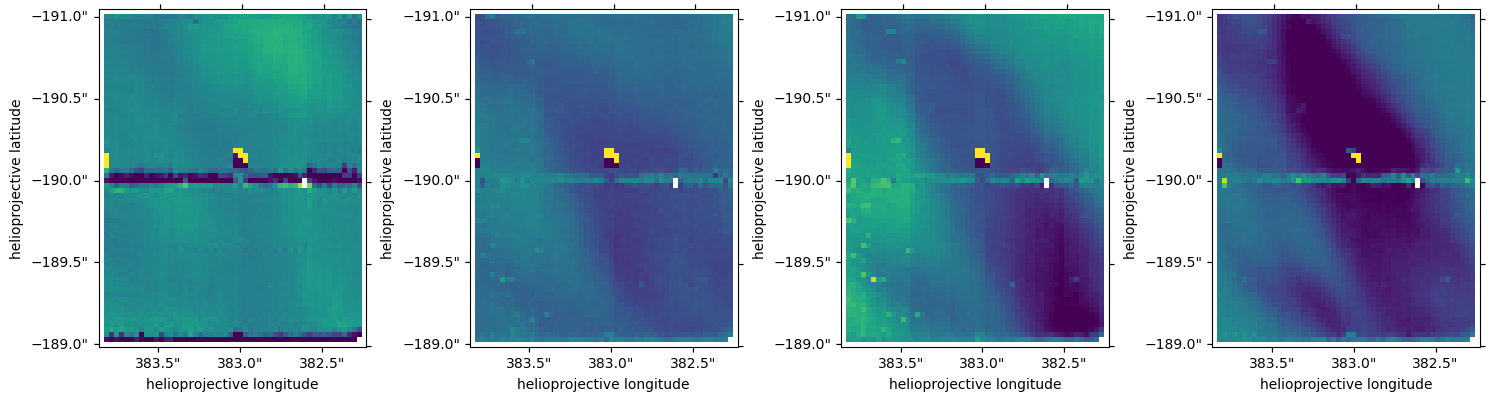

In [9]:
## Show the Stokes image from a single tile, taking a slice in the wavelength-direction
fig = plt.figure(figsize=(15,5))

for iS in range(0,nS):
    if iS == 0:
        vran = (0.5,1.1)
    else:
        vran = (-0.05,0.05)
        
    ax = fig.add_subplot(1,4,iS+1, projection=tds[xt0,yt0][iS,w0,:,:])
    tds[xt0,yt0][iS,w0,:,:].plot(axes=ax, aspect='equal', vmin=vran[0], vmax=vran[1])

plt.tight_layout()
plt.show()

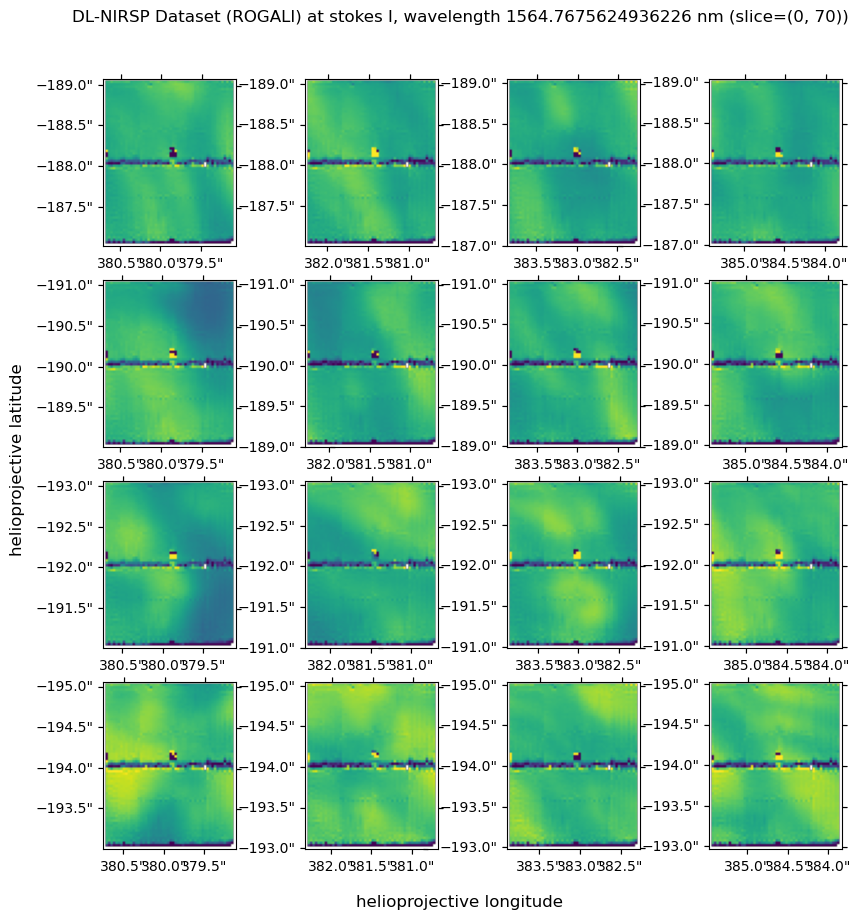

In [10]:
## Show a the same slice in wavelength over several tiles, showing all the mosaic tiles is possible, but takes more time
fig = plt.figure(figsize=(10,10))
tds[xt0-2:xt0+2,yt0-2:yt0+2].plot(slice_index=(0,70), share_zscale=True, vmin=0.5, vmax=1.1)
plt.show()

Notice in this figure, that the run of position values on the x and y axes are reversed with respect to the order that the tiles are in.

## Regridding DL-NIRSP data the DKIST way, with Reproject

In [11]:
from reproject.mosaicking import find_optimal_celestial_wcs, reproject_and_coadd
from reproject import reproject_interp

from ndcube import NDCube

In [12]:
w0tiles = tds.slice_tiles[0,w0,:,:]

In [13]:
reference_wcs, shape_out = find_optimal_celestial_wcs(
    [f.wcs for f in w0tiles.flat],
    auto_rotate=True,
    # We drop the output resolution to reduce memory usage
    # remove this line to run at the native resolution of the input data
    resolution=0.15*u.arcsec,
)

# Due to a bug in reproject we need to reverse the direction of the longitude axis
# https://github.com/astropy/reproject/issues/431
reference_wcs.wcs.cdelt[0] = -reference_wcs.wcs.cdelt[0]

/var/folders/tk/4ztr44zd507_0fl_zvcjk8k00000gn/T/ipykernel_89500/4202751975.py:1: DeprecationWarning: negative_lon_cdelt is not set, and currently defaults to True, but in future will change to 'auto', and for this WCS this will evaluate to False in future. It is recommended that you set negative_lon_cdelt explicitly, either to 'auto', or to True/False.
  reference_wcs, shape_out = find_optimal_celestial_wcs(


In [14]:
arr, footprint = reproject_and_coadd(
    w0tiles.flat,
    reference_wcs,
    reproject_function=reproject_interp,
    shape_out=shape_out,
    roundtrip_coords=False,
)

2026-01-27 13:24:39 - reproject.mosaicking.coadd - INFO: Output mosaic will have shape (173, 305)
2026-01-27 13:24:39 - reproject.mosaicking.coadd - INFO: Using on-the-fly mode for adding individual reprojected images to output array
2026-01-27 13:24:39 - reproject.mosaicking.coadd - INFO: Processing input data 1 of 377
2026-01-27 13:24:39 - reproject.mosaicking.coadd - INFO: Calling reproject_interp with shape_out=(12, 12)
2026-01-27 13:24:39 - reproject.mosaicking.coadd - INFO: Adding reprojected array to final array
2026-01-27 13:24:39 - reproject.mosaicking.coadd - INFO: Processing input data 2 of 377
2026-01-27 13:24:39 - reproject.mosaicking.coadd - INFO: Calling reproject_interp with shape_out=(15, 12)
2026-01-27 13:24:39 - reproject.mosaicking.coadd - INFO: Adding reprojected array to final array
2026-01-27 13:24:39 - reproject.mosaicking.coadd - INFO: Processing input data 3 of 377
2026-01-27 13:24:39 - reproject.mosaicking.coadd - INFO: Calling reproject_interp with shape_out

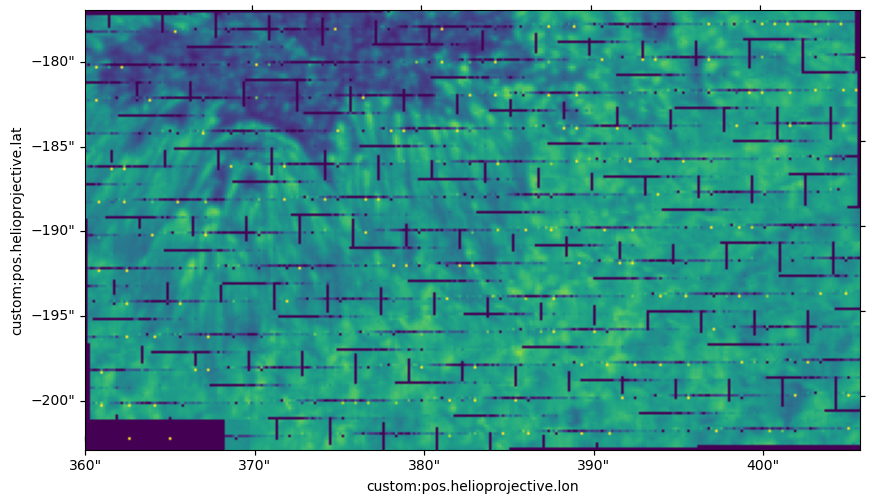

In [15]:
plt.figure(figsize=(10,10))
stitched = NDCube(arr, reference_wcs)
stitched.plot(vmin=0.5, vmax=1.1, aspect='equal')
plt.show()

Not very pretty.  We'll see about clearing up missing data and residual calibration issues in subsequent notebooks.

## Determining the scan order from metadata

In [16]:
## Get all the coordinate information for a single tile
coords,wavel,stks = tds[xt0,yt0].axis_world_coords()

In [17]:
coords

<SkyCoord (Helioprojective: obstime=2024-10-15T20:02:38.856, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2024-10-15T20:02:38.856, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
    (0.00160717, 5.79622056, 1.49132719e+11)>): (Tx, Ty) in arcsec
    [[(383.84897799, -189.00189552), (383.81868775, -189.00210293),
      (383.78839752, -189.00231035), ..., (382.30417581, -189.01247348),
      (382.27388557, -189.01268089), (382.24359533, -189.0128883 )],
     [(383.84918254, -189.03218151), (383.8188923 , -189.03238893),
      (383.78860206, -189.03259634), ..., (382.30438036, -189.04275947),
      (382.27409012, -189.04296688), (382.24379988, -189.04317429)],
     [(383.84938708, -189.06246751), (383.81909684, -189.06267492),
      (383.78880661, -189.06288233), ..., (382.3045849 , -189.07304546),
      (382.27429466, -189.07325287), (382.24400442, -189.07346028)],
     ...,
     [(383.86227341, -190.97048495), (383.83198318, -190.97069236),
      (383.80

In [18]:
wavel

<SpectralCoord [1564.31917193, 1564.32557751, 1564.33198309, 1564.33838867,
   1564.34479425, 1564.35119983, 1564.35760541, 1564.36401099,
   1564.37041657, 1564.37682215, 1564.38322773, 1564.38963331,
   1564.39603889, 1564.40244446, 1564.40885004, 1564.41525562,
   1564.4216612 , 1564.42806678, 1564.43447236, 1564.44087794,
   1564.44728352, 1564.4536891 , 1564.46009468, 1564.46650026,
   1564.47290584, 1564.47931142, 1564.485717  , 1564.49212258,
   1564.49852816, 1564.50493374, 1564.51133932, 1564.51774489,
   1564.52415047, 1564.53055605, 1564.53696163, 1564.54336721,
   1564.54977279, 1564.55617837, 1564.56258395, 1564.56898953,
   1564.57539511, 1564.58180069, 1564.58820627, 1564.59461185,
   1564.60101743, 1564.60742301, 1564.61382859, 1564.62023417,
   1564.62663975, 1564.63304533, 1564.6394509 , 1564.64585648,
   1564.65226206, 1564.65866764, 1564.66507322, 1564.6714788 ,
   1564.67788438, 1564.68428996, 1564.69069554, 1564.69710112,
   1564.7035067 , 1564.70991228, 1564.7163

In [19]:
stks

StokesCoord(['I', 'Q', 'U', 'V'])

In [20]:
tds[xt0,yt0].headers

SIMPLE,BITPIX,NAXIS,NAXIS1,NAXIS2,NAXIS3,BUNIT,DATE,DATE-BEG,DATE-END,TELAPSE,DATE-AVG,ORIGIN,TELESCOP,OBSRVTRY,NETWORK,INSTRUME,OBJECT,CHECKSUM,DATASUM,WCSAXES,WCSAXESA,WCSNAME,WCSNAMEA,CRPIX1,CRPIX2,CRPIX3,CRPIX1A,CRPIX2A,CRPIX3A,CRVAL1,CRVAL2,CRVAL3,CRVAL1A,CRVAL2A,CRVAL3A,CDELT1,CDELT2,CDELT3,CDELT1A,CDELT2A,CDELT3A,CUNIT1,CUNIT2,CUNIT3,CUNIT1A,CUNIT2A,CUNIT3A,CTYPE1,CTYPE2,CTYPE3,CTYPE1A,CTYPE2A,CTYPE3A,PC1_1,PC1_2,PC1_3,PC2_1,PC2_2,PC2_3,PC3_1,PC3_2,PC3_3,PC1_1A,PC1_2A,PC1_3A,PC2_1A,PC2_2A,PC2_3A,PC3_1A,PC3_2A,PC3_3A,PV3_0,PV3_1,PV3_2,LONPOLE,LONPOLEA,TAZIMUTH,ELEV_ANG,TELTRACK,TTBLANGL,TTBLTRCK,DATEREF,OBSGEO-X,OBSGEO-Y,OBSGEO-Z,SPECSYS,VELOSYS,OBS_VR,MAXIS,MAXIS1,MAXIS2,MINDEX1,MINDEX2,WCSVALID,SOLARRAD,DSETID,POINT_ID,FRAMEVOL,PROCTYPE,RRUNID,RECIPEID,RINSTID,EXTNAME,SOLARNET,OBS_HDU,FILENAME,CADENCE,CADMIN,CADMAX,CADVAR,LEVEL,HEADVERS,HEAD_URL,INFO_URL,CALVERS,CAL_URL,IDSPARID,IDSOBSID,IDSCALID,WKFLNAME,WKFLVERS,NSPECLNS,SPECLN01,MANPROCD,PRODUCT,DNAXIS,DNAXIS1,DNAXIS2,DNAXIS3,DNAXIS4,DTYPE1,DTYPE2,DTYPE3,DTYPE4,DPNAME1,DPNAME2,DPNAME3,DPNAME4,DWNAME1,DWNAME2,DWNAME3,DWNAME4,DUNIT1,DUNIT2,DUNIT3,DUNIT4,DAAXES,DEAXES,DINDEX4,LINEWAV,WAVEBAND,WAVEUNIT,WAVEREF,WAVEMIN,WAVEMAX,CNAME1,CNAME2,CNAME3,DATAMIN,DATAMAX,DATAMEAN,DATAMEDN,DATAP01,DATAP02,DATAP05,DATAP10,DATAP25,DATAP75,DATAP90,DATAP95,DATAP98,DATAP99,DATARMS,DATAKURT,DATASKEW,FILE_ID,DKISTVER,OBSPR_ID,EXPER_ID,PROP_ID,DSP_ID,IP_ID,HLSVERS,NPROPOS,PROPID01,NEXPERS,EXPRID01,OCS_CTRL,FIDO_CFG,DSHEALTH,DSPSREPS,DSPSNUM,LIGHTLVL,LYOTSTAT,CAM_ID,CAMERA,BITDEPTH,XPOSURE,TEXPOSUR,CAM_FPS,CHIPDIM1,CHIPDIM2,HWBIN1,HWBIN2,SWBIN1,SWBIN2,NSUMEXP,SWNROI,SWROI1OX,SWROI1OY,SWROI1SX,SWROI1SY,HWNROI,HWROI1OX,HWROI1OY,HWROI1SX,HWROI1SY,NBIN1,NBIN2,NBIN3,NBIN,FPABITPX,GOS_STAT,LVL3STAT,LAMPSTAT,LVL2STAT,POLANGLE,LVL1STAT,RETANGLE,LVL0STAT,APERTURE,LGOSSTAT,GOS_TEMP,POL_NOIS,POL_SENS,STOKES,ATMOS_R0,AO_LOCK,AO_LOCKX,AO_LOCKY,WFSLOCKX,WFSLOCKY,LIMBRPOS,LIMBRATE,OOBSHIFT,WSSOURCE,WIND_SPD,WIND_DIR,WS_TEMP,WS_HUMID,WS_DEWPT,WS_PRESS,SKYBRIGT,DLARMID,DLARMPS,DLARMFC,DLFILT,DLWAV,DLFWHM,DLFLTPOS,DLPOLMD,DLMODID,DLMOD,DLMODRT,DLNUMST,DLGRTID,DLGRTCN,DLGRTBA,DLGRTAN,DLNDATAC,DLCOADD,DLFRATIO,DLF4POS,DLF1POS,DLIFU,DLIFUPOS,DLSLITMD,DLSLIT,DLSLITPS,DLMOSNRP,DLCURMOS,DLMSPAT,DLNSSTPX,DLSTPCPX,DLSTPX,DLCSTPX,DLNSSTPY,DLSTPCPY,DLSTPY,DLCSTPY,DLDMODE,DLDOFFX,DLDOFFY,DLCURSTP,DLCAMSMD,DLCAMSSQ,DLCAMNSF,DLCAMNS,DLCAMOFF,DLCAMTIM,DLARTEMP,DLCAMFID,DLMODT0
bool,int64,int64,int64,int64,int64,str1,str23,str26,str23,float64,str26,str26,str32,str40,str9,str8,str7,str16,str10,int64,int64,str25,str24,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str6,str6,str2,str3,str3,str2,str8,str8,str8,str8,str8,str4,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,str37,float64,str23,str26,float64,float64,float64,str8,float64,float64,int64,int64,int64,int64,int64,bool,float64,str6,str6,float64,str2,int64,int64,int64,str11,int64,int64,str61,float64,float64,float64,float64,int64,str6,str60,str26,str6,str88,int64,int64,int64,str27,str6,int64,str16,bool,str8,int64,int64,int64,int64,int64,str7,str7,str8,str6,str25,str24,str15,str18,str25,str24,str10,str18,str6,str6,str2,str1,int64,int64,int64,float64,str16,int64,str3,float64,float64,str25,str24,str10,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str32,str33,str39,str9,str9,str1,str16,str10,int64,str9,int64,str9,str4,str37,str7,int64,int64,float64,bool,str16,str11,int64,float64,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,str4,str5,str4,str5,str4,str5,str4,str21,str9,str4,float64,float64,float64,str1,float64,bool,float64,float64,float64,float6

If we compare the obstime in the SkyCoord array above, it looks like it is the mid-time between DATE-BEG and DATE-END values that we see in the header, so that's good.

In [21]:
tile_time = list()
tile_Tx = list()
tile_Ty = list()

for xti in range(0,nXtiles):
    for yti in range(0,nYtiles):
        coords, = tds[xti,yti][0,w0,:,:].axis_world_coords()
        
        tile_time.append(coords.obstime)
        tile_Tx.append(coords.Tx.mean().value)
        tile_Ty.append(coords.Ty.mean().value)

tile_time = np.array(tile_time)
tile_Tx = np.array(tile_Tx)
tile_Ty = np.array(tile_Ty)

In [22]:
## sort the coordinates using the time array
sidx = np.argsort(tile_time)

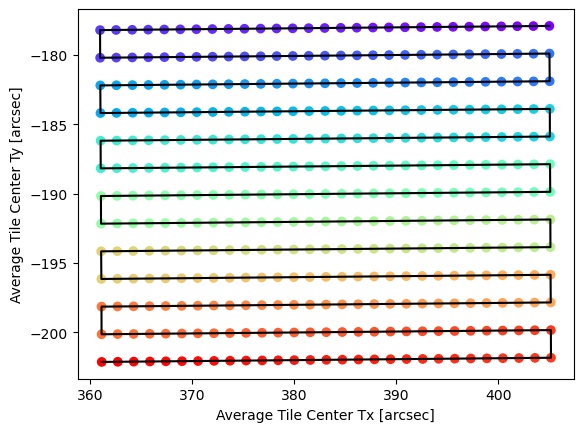

In [23]:
plt.plot(tile_Tx[sidx],tile_Ty[sidx], color='black')
plt.scatter(tile_Tx[sidx],tile_Ty[sidx], c=np.arange(nXtiles*nYtiles), cmap='rainbow')

plt.xlabel('Average Tile Center Tx [arcsec]')
plt.ylabel('Average Tile Center Ty [arcsec]')

plt.show()

## Ad Hoc Flat Field using local quiet Sun
Correct the mosaic using a flatfield made from the quiet sun tiles

In [24]:
## Make a coarse map using the average intensity for each mosaic tile
minimap_I = np.zeros([nYtiles,nXtiles])

for yi in range(0,nYtiles):
    for xi in range(0,nXtiles):
        minimap_I[yi,xi] = np.nanmean(tds[xi,yi].data[0,:,:,:]) #stokes I continuum

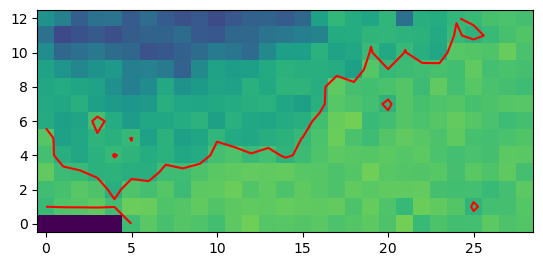

In [25]:
## Use the minimap to define a mask for the tiled dataset
thresh_qs = 0.9
mask_qs = (minimap_I > thresh_qs).transpose() #transpose mask to apply to tiled dataset

plt.imshow(minimap_I, origin='lower', vmin=0.5, vmax=1.1)
plt.contour(minimap_I, levels=[thresh_qs], colors=['red'])

plt.show()

In [26]:
## Make an average tile from all the Stokes I quiet Sun tiles
## Average over the spectral dimension, leaving just the two spatial dimensions for each tile
avg_tile = np.zeros([nY,nX])
count = 0

for ds in tds[mask_qs]:
    avg_tile += np.nanmean(ds.data[0,:,:,:].compute(), axis=0)
    count += 1

avg_tile /= count

/var/folders/tk/4ztr44zd507_0fl_zvcjk8k00000gn/T/ipykernel_89500/3084885777.py:7: RuntimeWarning: Mean of empty slice
  avg_tile += np.nanmean(ds.data[0,:,:,:].compute(), axis=0)


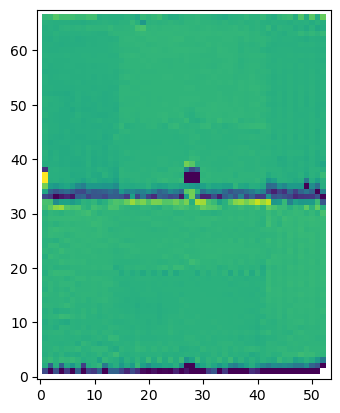

In [27]:
#show the average tile
plt.imshow(avg_tile, origin='lower', vmin=0.5, vmax=1.2)
plt.show()

## Make a basic quicklook
Use the ad hoc flat field to correct the data

In [49]:
## Calculate the quicklook metrics and extract the world coordinates
## for every spatial pixel in the dataset
cont_w0,cont_w1 = (50, 60)
line_w0,line_w1 = (60, 80)

dl_Tx = np.zeros([nXtiles,nYtiles,nY,nX])
dl_Ty = np.zeros([nXtiles,nYtiles,nY,nX])
dl_cont = np.zeros([nXtiles,nYtiles,nY,nX])
dl_stkv = np.zeros([nXtiles,nYtiles,nY,nX])

for iXt in range(0,nXtiles):
    for iYt in range(0,nYtiles):
        ds = tds[iXt,iYt]

        dl_coord, = ds[0,0,:,:].axis_world_coords()
        dl_Tx[iXt,iYt,:,:] = dl_coord.Tx.value
        dl_Ty[iXt,iYt,:,:] = dl_coord.Ty.value
        
        dl_cont[iXt,iYt,:,:] = np.nanmean(ds[0,cont_w0:cont_w1,:,:].data, axis=0) / avg_tile
        dl_stkv[iXt,iYt,:,:] = np.nanmean(ds[3,line_w0:line_w1,:,:].data, axis=0) / avg_tile

/var/folders/tk/4ztr44zd507_0fl_zvcjk8k00000gn/T/ipykernel_89500/2593890319.py:8: RuntimeWarning: Mean of empty slice
  spat_img = np.nanmean(tds[xt0,yt0][0,cont_w0:cont_w1,:,:].data.compute(), axis=0)


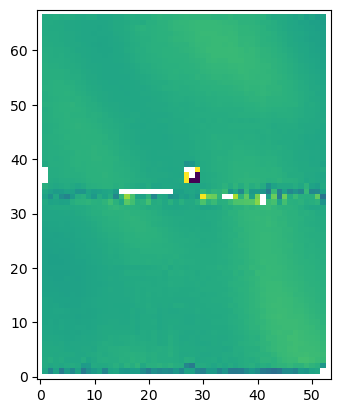

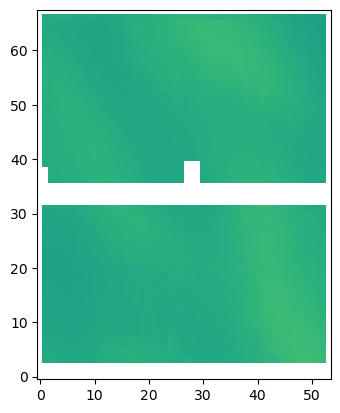

In [50]:
## Define a tile mask to reduce edge effects further
tile_mask = np.ones([nY,nX])
tile_mask[32:36,:] = np.nan
tile_mask[0:3,:] = np.nan
tile_mask[36:39,0:2] = np.nan
tile_mask[36:40,27:30] = np.nan

spat_img = np.nanmean(tds[xt0,yt0][0,cont_w0:cont_w1,:,:].data.compute(), axis=0)

plt.imshow(spat_img/avg_tile, origin='lower', vmin=0, vmax=1.5)
plt.show()

plt.imshow(spat_img/avg_tile*tile_mask, origin='lower', vmin=0, vmax=1.5)
plt.show()

In [51]:
## Remap data in solar coordinates, this is an alternalte method from reproject 
## and gives more control about what data is going into the interpolation.
## Set up a new common coordinate grid for the whole mosaic
x0 = dl_Tx.min()
x1 = dl_Tx.max()
y0 = dl_Ty.min()
y1 = dl_Ty.max()

dx = tds[0,0].headers[0]['CDELT1'] #nominal arcsec/pixel scale
dy = tds[0,0].headers[0]['CDELT2']

new_nX = int((x1-x0)/dx)
new_nY = int((y1-y0)/dy)

new_xcoord,new_ycoord = np.meshgrid(np.mgrid[0:new_nX]*dx+x0,
                                    np.mgrid[0:new_nY]*dy+y0)
        
xy_out = np.array([new_xcoord.flatten(), 
                   new_ycoord.flatten()]).transpose()

## Remap the continuum
good = np.isfinite(dl_cont*tile_mask)

values_in = dl_cont[good]
xy_in = np.array([dl_Tx[good], dl_Ty[good]]).transpose()

## "nearest" is fast but produces some weird edge effects,
## "linear" treatment of missing edge data is better, but takes more time
values_out = griddata(xy_in, values_in, xy_out, method='nearest') 
dlremap_cont = values_out.reshape(new_nY,new_nX)

## Remap Stokes V
good = np.isfinite(dl_stkv*tile_mask)

values_in = dl_stkv[good]
xy_in = np.array([dl_Tx[good], dl_Ty[good]]).transpose()

values_out = griddata(xy_in, values_in, xy_out, method='nearest')
dlremap_stkv = values_out.reshape(new_nY,new_nX)

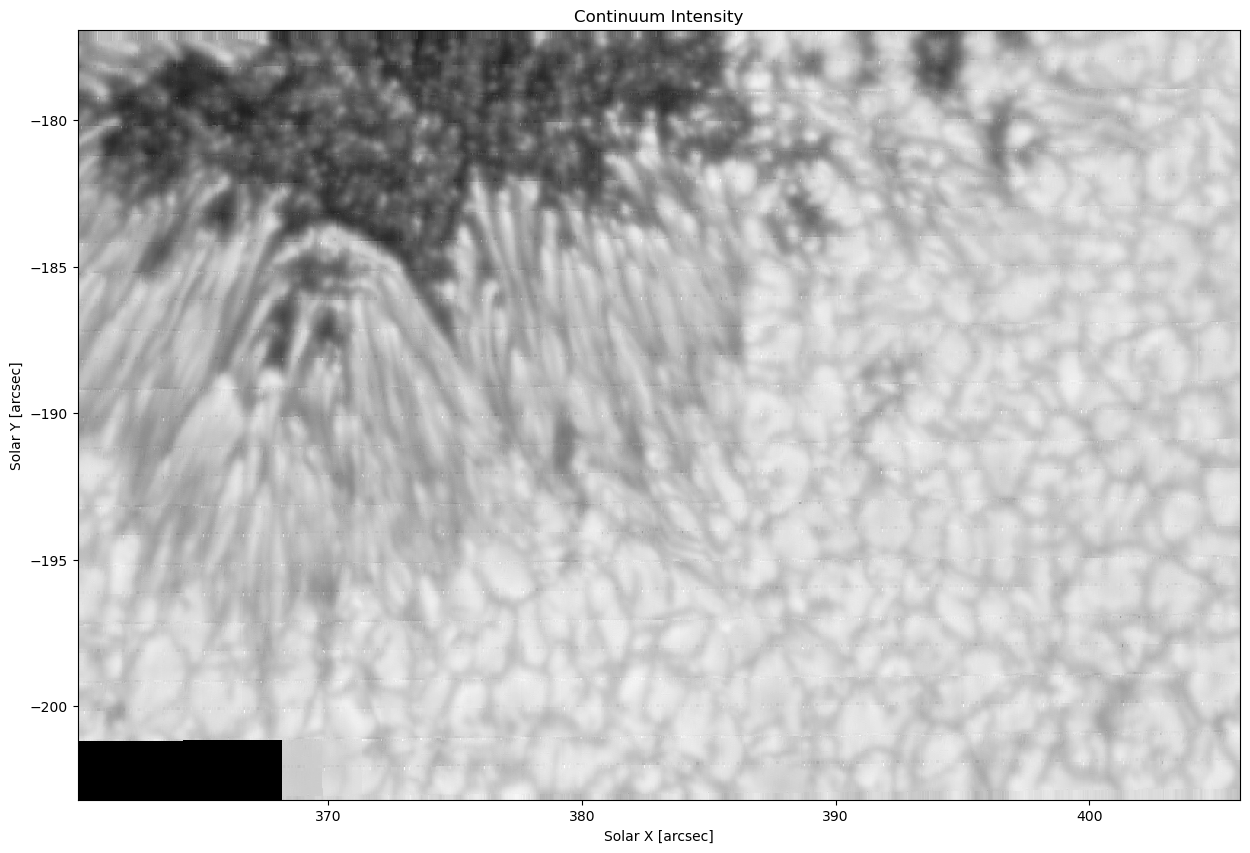

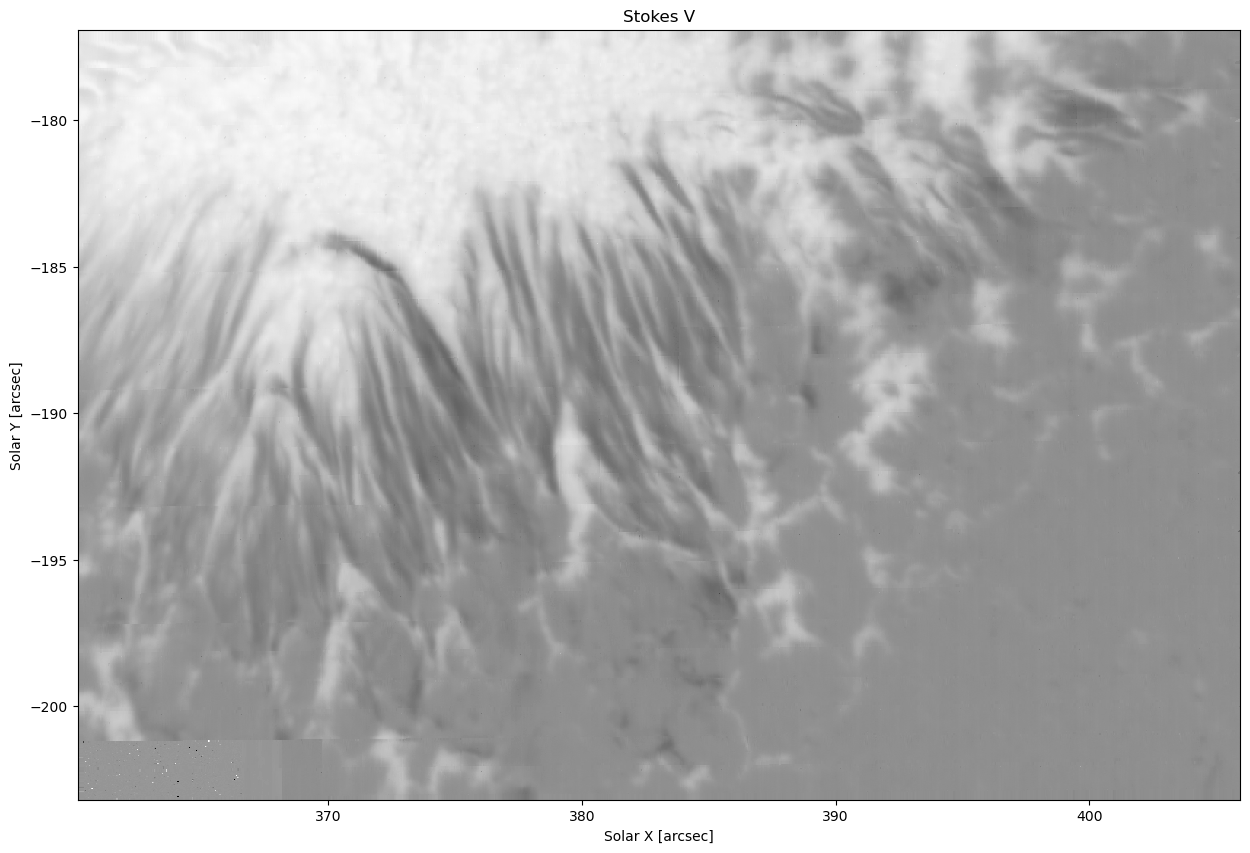

In [52]:
fig = plt.figure(figsize=(15,10))
plt.pcolormesh(new_xcoord, new_ycoord, dlremap_cont, vmin=0.5, vmax=1.2, cmap='Greys_r')
plt.xlabel('Solar X [arcsec]')
plt.ylabel('Solar Y [arcsec]')
plt.title('Continuum Intensity')
plt.show()

fig = plt.figure(figsize=(15,10))
plt.pcolormesh(new_xcoord, new_ycoord, dlremap_stkv, vmin=-0.05, vmax=0.05, cmap='Greys_r')
plt.xlabel('Solar X [arcsec]')
plt.ylabel('Solar Y [arcsec]')
plt.title('Stokes V')
plt.show()